In [3]:
import pandas as pd

# Đọc file CSV đã được tiền xử lý
csv_path = "cleaned_order_history.csv"
df = pd.read_csv(csv_path)

# Hiển thị các cột để kiểm tra cấu trúc
df.columns


Index(['Restaurant ID', 'Restaurant name', 'Subzone', 'City', 'Order ID',
       'Order Placed At', 'Order Status', 'Delivery', 'Distance',
       'Items in order', 'Discount construct', 'Bill subtotal',
       'Packaging charges', 'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating',
       'Cancellation / Rejection reason',
       'Restaurant compensation (Cancellation)', 'KPT duration (minutes)',
       'Rider wait time (minutes)', 'Order Ready Marked',
       'Customer complaint tag', 'Customer ID'],
      dtype='object')

In [4]:
# Lọc các dòng có 'Order Market Value' là "Incorrected"
incorrected_rows = df[df['Order Ready Marked'] == "Incorrectly"]

# In ra kết quả
print(incorrected_rows)

print(f"Số dòng có Order Ready Marked là 'incorrectly': {len(incorrected_rows)}")


       Restaurant ID    Restaurant name                  Subzone       City  \
6           20320607              Swaad                 Sector 4  Delhi NCR   
18          20320607              Swaad                 Sector 4  Delhi NCR   
26          20320607              Swaad                 Sector 4  Delhi NCR   
32          20320607              Swaad                 Sector 4  Delhi NCR   
33          20320607              Swaad                 Sector 4  Delhi NCR   
...              ...                ...                      ...        ...   
21255       21143186  Tandoori Junction  Greater Kailash 2 (GK2)  Delhi NCR   
21259       21145152  Tandoori Junction                 Sector 4  Delhi NCR   
21292       21309083              Swaad               Sector 135  Delhi NCR   
21297       21309083              Swaad               Sector 135  Delhi NCR   
21318       21523055    Masala Junction                 Sector 4  Delhi NCR   

         Order ID      Order Placed At Order Status

In [5]:
from sklearn.model_selection import train_test_split

# Tách train-test theo tỉ lệ 80:20
train_df, test_df = train_test_split(incorrected_rows, test_size=0.2, random_state=42)

# In số dòng
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")


Train size: 1516, Test size: 379


0th percentile: 0.20 phút
10th percentile: 3.40 phút
25th percentile: 4.50 phút
50th percentile: 7.20 phút
70th percentile: 10.10 phút
85th percentile: 13.56 phút
90th percentile: 15.50 phút
95th percentile: 18.70 phút
99th percentile: 26.54 phút
100th percentile: 73.80 phút


C:\Users\krizb\AppData\Local\Temp\ipykernel_24960\2258542518.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_incorrect_ready['Wait Time Group'] = pd.cut(


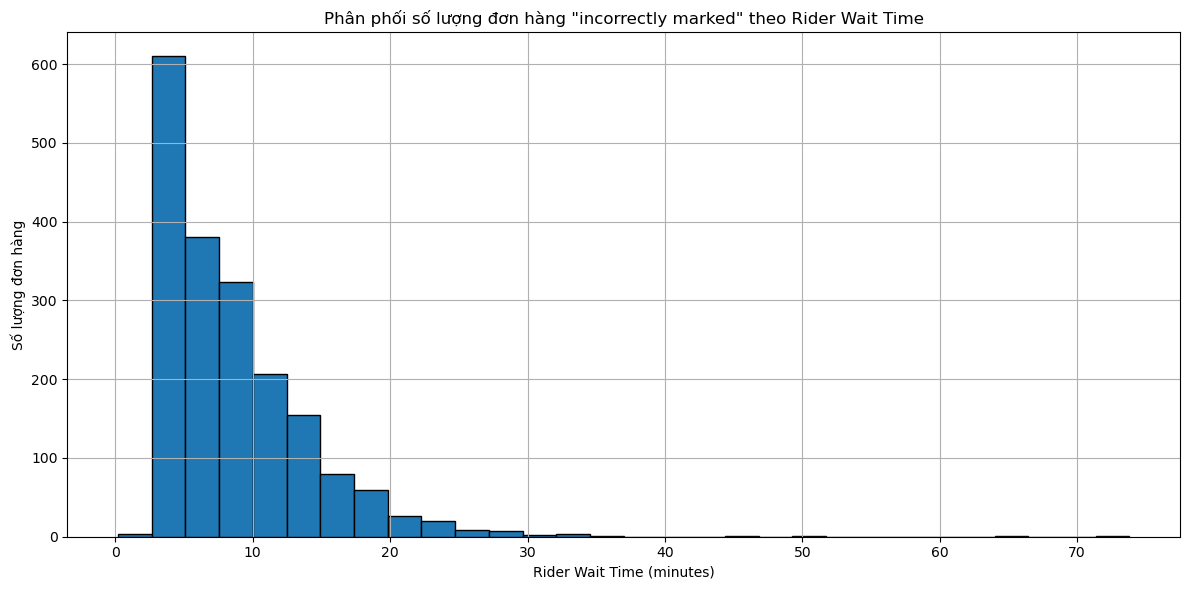

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Không dùng train-test, dùng toàn bộ dữ liệu có Order Ready Marked = 'incorrectly'
df_incorrect_ready = df[df['Order Ready Marked'].str.lower() == 'incorrectly']

# Tính phân vị rider wait time
rider_wait_times = df_incorrect_ready['Rider wait time (minutes)'].dropna()
percentiles = [0, 10, 25, 50, 70 ,85, 90, 95, 99, 100]
percentile_values = rider_wait_times.quantile([p/100 for p in percentiles])

# Hiển thị kết quả
for p, value in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {value:.2f} phút")

# Tạo DataFrame chứa phân vị
custom_percentile_df = percentile_values.reset_index()
custom_percentile_df.columns = ['Percentile', 'Rider Wait Time (minutes)']

# Loại trùng và đảm bảo tăng dần
bins = sorted(set(custom_percentile_df['Rider Wait Time (minutes)'].tolist()))

# Tạo labels tương ứng với số khoảng (bins - 1)
labels = [f"{percentiles[i]}-{percentiles[i+1]}%" for i in range(len(bins) - 1)]

# Cắt dữ liệu thành nhóm
df_incorrect_ready['Wait Time Group'] = pd.cut(
    df_incorrect_ready['Rider wait time (minutes)'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Đếm số lượng đơn hàng theo từng nhóm
group_counts = df_incorrect_ready['Wait Time Group'].value_counts().sort_index()

# Tính midpoint các khoảng để vẽ biểu đồ
mid_points = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]

# Vẽ biểu đồ phân bố dạng histogram theo Rider wait time
plt.figure(figsize=(12, 6))
plt.hist(incorrected_rows['Rider wait time (minutes)'].dropna(), bins=30, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.grid(True)
plt.tight_layout()
plt.show()


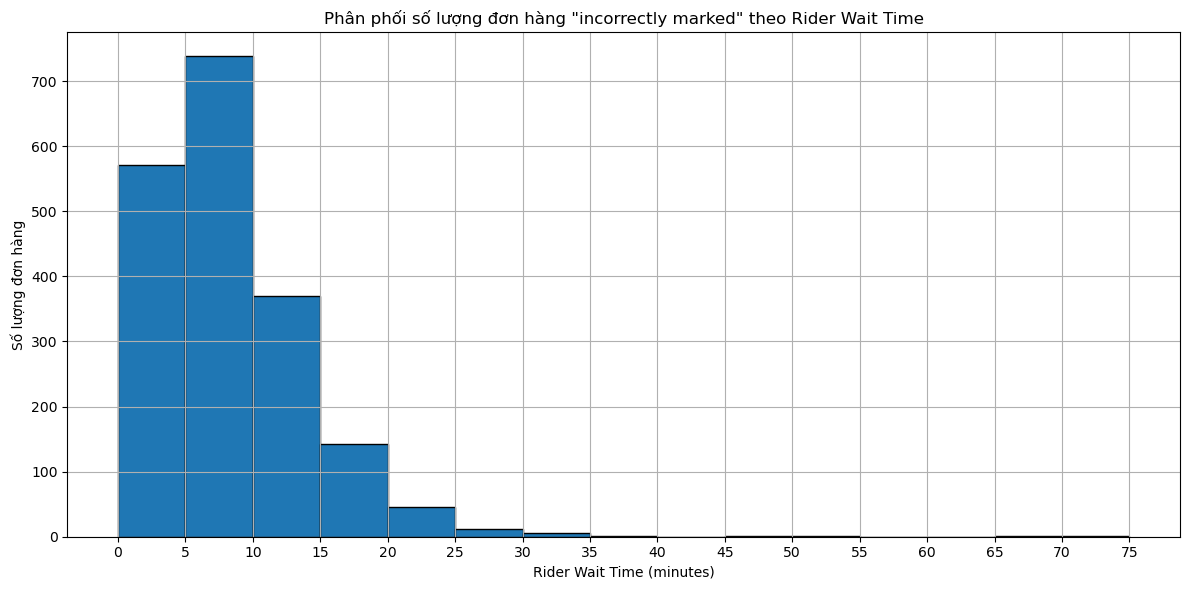

In [7]:
import numpy as np

# Tạo bins mỗi 5 phút
max_time = int(rider_wait_times.max()) + 5
bins = np.arange(0, max_time + 1, 5)  # ví dụ: 0, 5, 10, ..., max

# Vẽ histogram
plt.figure(figsize=(12, 6))
plt.hist(rider_wait_times, bins=bins, edgecolor='black')
plt.title('Phân phối số lượng đơn hàng "incorrectly marked" theo Rider Wait Time')
plt.xlabel('Rider Wait Time (minutes)')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(bins)  # Set nhãn trục x đúng mỗi 5 phút
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
filtered_rows = incorrected_rows[incorrected_rows["Rider wait time (minutes)"] > 7]

# Tạo hàm đếm số dòng thỏa điều kiện
def count_filtered_rows():
    return len(filtered_rows)

# In ra kết quả
print("Số dòng có 'Rider wait time (minutes)' > 7 trong 'incorrected_rows':", count_filtered_rows())

filtered_rows.to_csv("filtered_wait_time_7_plus.csv", index=False)


Số dòng có 'Rider wait time (minutes)' > 7 trong 'incorrected_rows': 979


In [11]:
# Tính tỷ lệ giữa số dòng filtered_rows và incorrected_rows
ratio = len(filtered_rows) / len(incorrected_rows)

# Chuyển tỷ lệ thành phần trăm, làm tròn 2 chữ số
percentage = round(ratio * 100, 2)
print("Tỷ lệ giữa những đơn hàng incorrectly có rider wait time > 7 phút và tổng số đơn hàng incorrectly: ", percentage)



Tỷ lệ giữa những đơn hàng incorrectly có rider wait time > 7 phút và tổng số đơn hàng incorrectly:  51.66


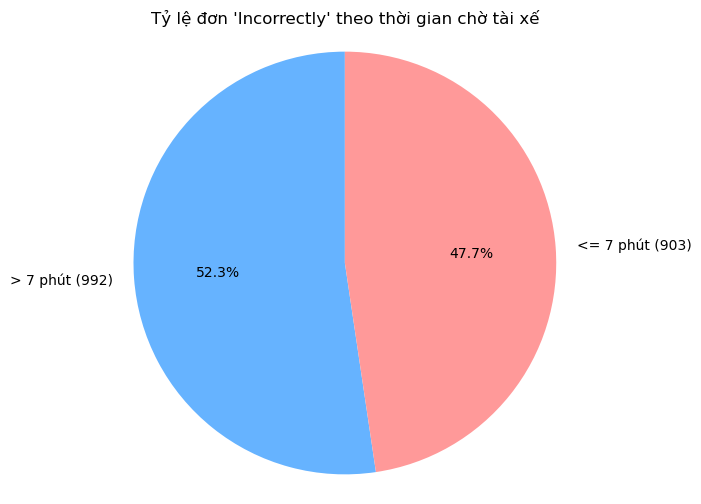

In [12]:
import matplotlib.pyplot as plt

# Bước 1: Tạo 2 nhóm theo thời gian chờ
counts = incorrected_rows['Rider wait time (minutes)'].apply(lambda x: '> 7 phút' if x >= 7 else '<= 7 phút').value_counts()

# Bước 2: Gán nhãn và giá trị
labels = [f'{label} ({counts[label]})' for label in counts.index]
sizes = counts.values
colors = ['#66b3ff', '#ff9999']

# Bước 3: Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Tỷ lệ đơn 'Incorrectly' theo thời gian chờ tài xế")
plt.axis('equal')  # Đảm bảo hình tròn
plt.show()
